# 🩺 Prophet Diagnostics: Validation & Metrics

In traditional Machine Learning, we randomly split data into Train/Test sets. In Time Series, we cannot do this (random shuffling breaks the time order).

Instead, Prophet uses **Simulated Historical Forecasts** (also known as "Rolling Origin" Cross Validation).

## 1. How Cross-Validation Works in Prophet
Prophet "cuts" the history at a certain point, trains the model using data up to that cut-off, and then forecasts a specific distance into the future. It then moves the cut-off forward and repeats.



It requires three key parameters:
1.  **Initial:** How much training data to use before making the *first* cut. (e.g., "Train on the first 5 years").
2.  **Period:** How much to slide the cutoff forward for the next test. (e.g., "Move forward by 180 days").
3.  **Horizon:** How far into the future to forecast at each step. (e.g., "Predict the next 365 days").

> **Analogy:** Imagine standing in 2020, predicting 2021. Then walking to mid-2020, predicting mid-2021. Then walking to 2021, predicting 2022. You generate multiple "test sets" from a single history.

---

## 2. Performance Metrics
Once Cross-Validation generates the predictions, we compare them to the actuals using the `performance_metrics` function. It calculates:

* **MSE (Mean Squared Error):** Punishment for large errors. Hard to interpret scale.
* **RMSE (Root Mean Squared Error):** In the same units as your data. (e.g., "We are off by +/- 50 units").
* **MAE (Mean Absolute Error):** The average absolute size of the error. Robust to outliers.
* **MAPE (Mean Absolute Percentage Error):** The error as a percentage. (e.g., "We are off by 5%"). Very useful for business stakeholders.
* **Coverage:** What percent of the actual data fell inside the "Uncertainty Interval" (the blue shade)? Ideally, with 80% intervals, this should be near 0.80.

---

## 3. Visualizing Performance
Prophet includes a built-in plotter `plot_cross_validation_metric`.



* **X-Axis (Horizon):** How far out the prediction was made (Day 1 vs Day 300).
* **Y-Axis (Metric):** The error (e.g., MAPE).
* **The Insight:** Usually, errors get worse the further out you predict. This plot shows you *exactly* when the model becomes unreliable. (e.g., "Accuracy is great for 30 days, but MAPE spikes after 60 days").

#### 1) Importing necessary Libraries:

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('Daily_Sales.csv')

In [3]:
df.head()

,date,sales
0,2013-01-01,12
1,2013-01-02,16
2,2013-01-03,16
3,2013-01-04,20
4,2013-01-05,16


In [4]:
df.shape

(1826, 2)

##### Restructuring Dataframe according to Prophet need:

In [6]:
df.columns = ['ds', 'y']

In [7]:
df.head()

,ds,y
0,2013-01-01,12
1,2013-01-02,16
2,2013-01-03,16
3,2013-01-04,20
4,2013-01-05,16


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ds      1826 non-null   object
 1   y       1826 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 28.7+ KB


In [10]:
df['ds'] = pd.to_datetime(df['ds'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1826 non-null   datetime64[ns]
 1   y       1826 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 28.7 KB


##### Visualizing Data:

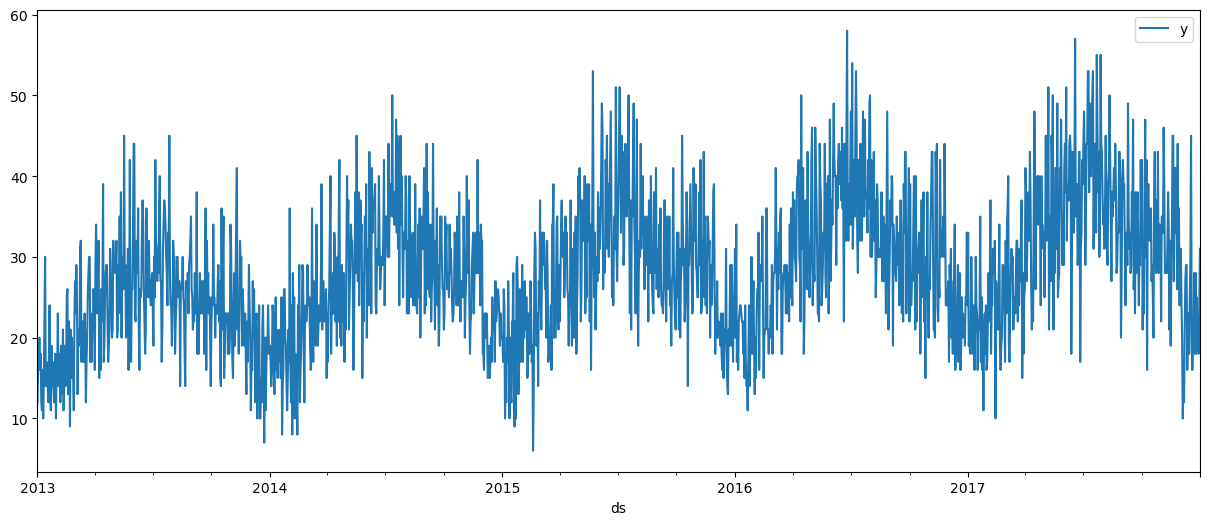

In [16]:
df.plot(x= 'ds', y= 'y', figsize= (15,6))
plt.show()

#### 3) Train Test Split:

In [17]:
len(df)

1826

In [19]:
train_data = df[:1461]
test_data = df[1461:]
print(train_data.shape, test_data.shape)

(1461, 2) (365, 2)


#### 4) Prophet Model:

In [20]:
model = Prophet()
model.fit(train_data)

18:13:25 - cmdstanpy - INFO - Chain [1] start processing
18:13:26 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
# Future Dataframe:

future_df = model.make_future_dataframe(periods= 365)
future_df.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [22]:
# Forecast:

forecast = model.predict(future_df)

In [23]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,22.142815,5.885399,19.832436,22.142815,22.142815,-9.261085,-9.261085,-9.261085,-2.125488,-2.125488,-2.125488,-7.135598,-7.135598,-7.135598,0.0,0.0,0.0,12.881730
1,2013-01-02,22.150740,5.671909,19.454081,22.150740,22.150740,-9.773363,-9.773363,-9.773363,-2.643845,-2.643845,-2.643845,-7.129518,-7.129518,-7.129518,0.0,0.0,0.0,12.377377
2,2013-01-03,22.158665,8.760317,21.351096,22.158665,22.158665,-7.207447,-7.207447,-7.207447,-0.071274,-0.071274,-0.071274,-7.136173,-7.136173,-7.136173,0.0,0.0,0.0,14.951218
3,2013-01-04,22.166590,10.635812,24.180068,22.166590,22.166590,-4.887829,-4.887829,-4.887829,2.266867,2.266867,2.266867,-7.154696,-7.154696,-7.154696,0.0,0.0,0.0,17.278761
4,2013-01-05,22.174515,12.117211,25.854899,22.174515,22.174515,-3.559795,-3.559795,-3.559795,3.624169,3.624169,3.624169,-7.183964,-7.183964,-7.183964,0.0,0.0,0.0,18.614720


In [28]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2013-01-01,12.881730,5.885399,19.832436
1,2013-01-02,12.377377,5.671909,19.454081
2,2013-01-03,14.951218,8.760317,21.351096
3,2013-01-04,17.278761,10.635812,24.180068
4,2013-01-05,18.614720,12.117211,25.854899


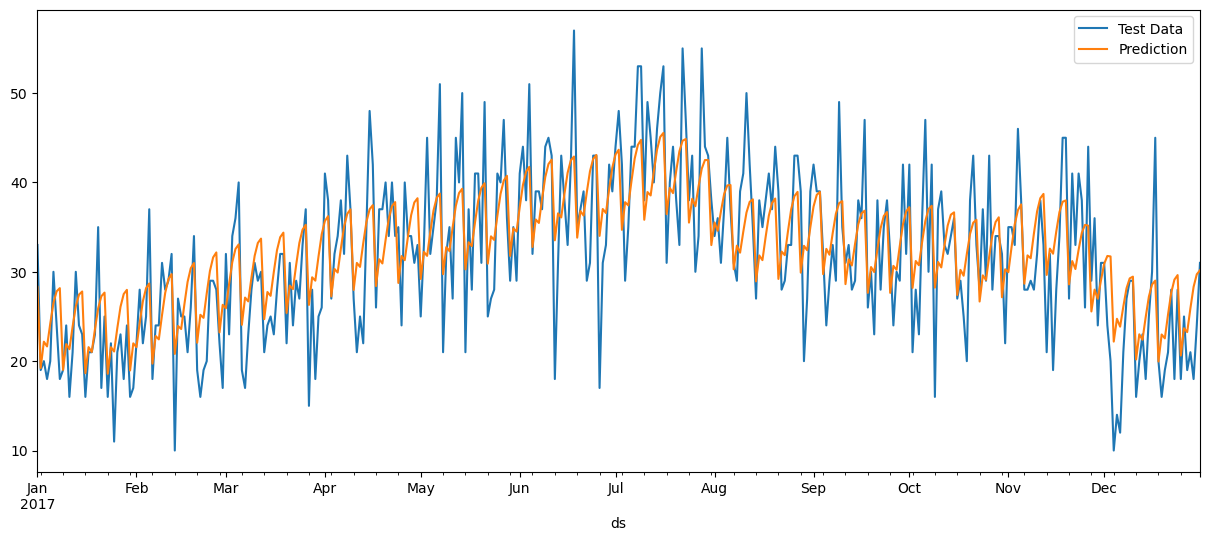

In [30]:
# Plotting Test Data vs Forecast:

ax = test_data.plot(x= 'ds', y= 'y', figsize= (15,6), label= 'Test Data', legend= True)
forecast[-365:].plot(x= 'ds', y= 'yhat', label= 'Prediction', legend= True, ax= ax)
plt.show()

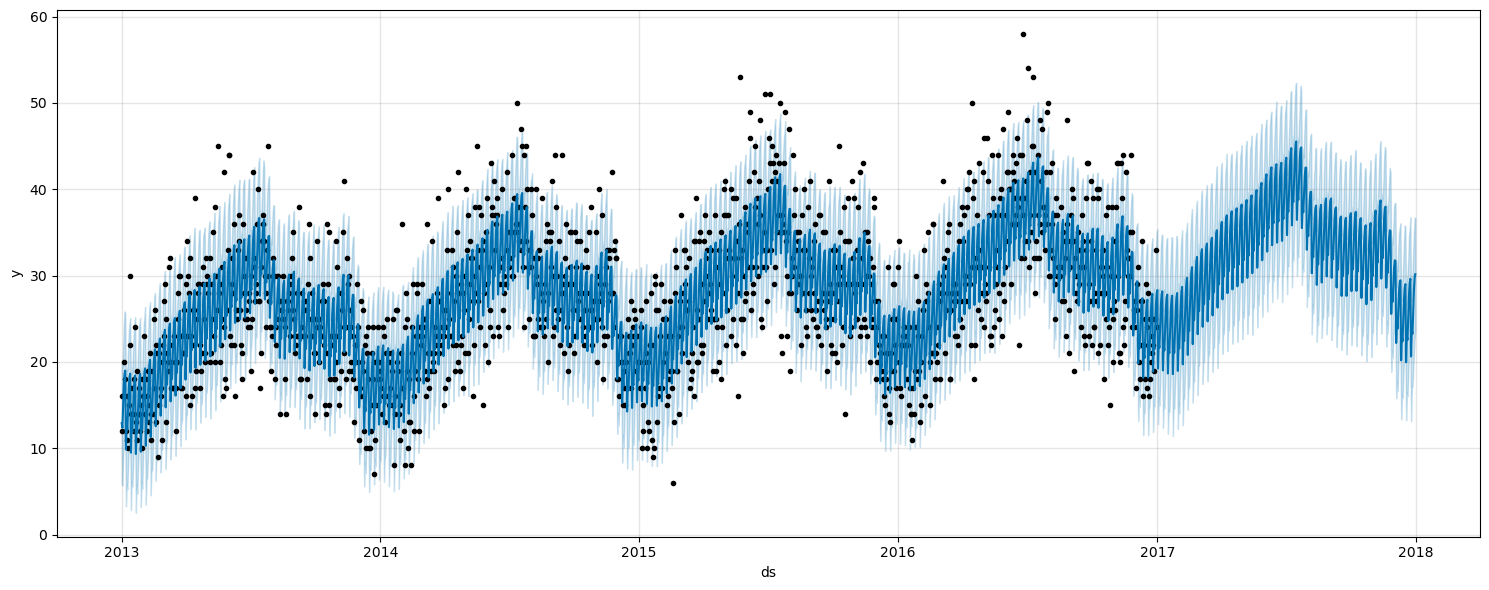

In [34]:
# Data vs Modelled Data:

model.plot(forecast, figsize= (15,6))
plt.show()

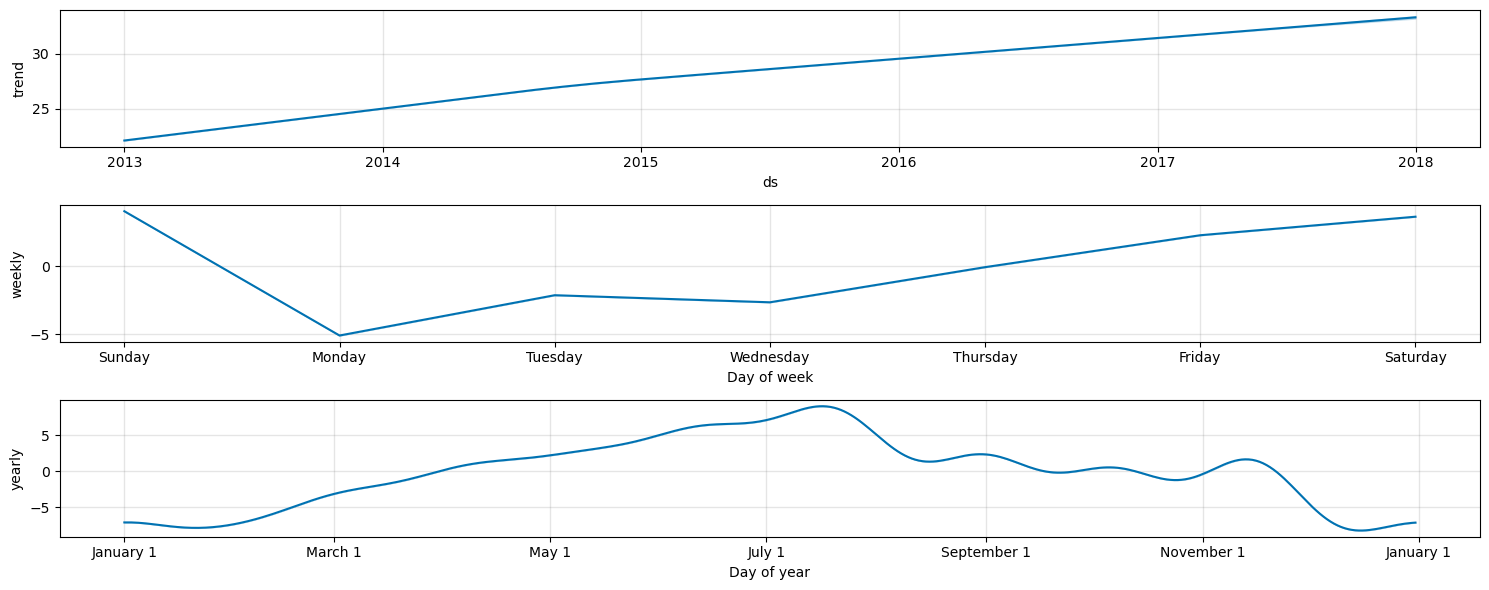

In [35]:
# Time Series Components:

model.plot_components(forecast, figsize= (15,6))
plt.show()

##### Model Evaluation Using RMSE:

In [36]:
np.sqrt(mean_squared_error(test_data['y'], forecast[-365:]['yhat']))

np.float64(5.801020064743999)

#### 5) Diagnostics Using Prophet Cross Validation and Performance Metrics:

In [37]:
cv = cross_validation(model= model,
                     initial= '730 days',
                     period= '45 days',
                     horizon= '90 days')

  0%|          | 0/15 [00:00<?, ?it/s]

18:33:16 - cmdstanpy - INFO - Chain [1] start processing
18:33:16 - cmdstanpy - INFO - Chain [1] done processing
18:33:17 - cmdstanpy - INFO - Chain [1] start processing
18:33:17 - cmdstanpy - INFO - Chain [1] done processing
18:33:17 - cmdstanpy - INFO - Chain [1] start processing
18:33:17 - cmdstanpy - INFO - Chain [1] done processing
18:33:17 - cmdstanpy - INFO - Chain [1] start processing
18:33:18 - cmdstanpy - INFO - Chain [1] done processing
18:33:18 - cmdstanpy - INFO - Chain [1] start processing
18:33:18 - cmdstanpy - INFO - Chain [1] done processing
18:33:18 - cmdstanpy - INFO - Chain [1] start processing
18:33:18 - cmdstanpy - INFO - Chain [1] done processing
18:33:19 - cmdstanpy - INFO - Chain [1] start processing
18:33:19 - cmdstanpy - INFO - Chain [1] done processing
18:33:19 - cmdstanpy - INFO - Chain [1] start processing
18:33:19 - cmdstanpy - INFO - Chain [1] done processing
18:33:20 - cmdstanpy - INFO - Chain [1] start processing
18:33:20 - cmdstanpy - INFO - Chain [1]

In [38]:
cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-12,16.993369,10.599259,23.419695,10,2015-01-11
1,2015-01-13,20.097987,13.536347,26.613379,20,2015-01-11
2,2015-01-14,19.949226,14.126625,26.109623,13,2015-01-11
3,2015-01-15,22.425463,16.446391,28.904604,12,2015-01-11
4,2015-01-16,23.978935,17.667197,30.516489,22,2015-01-11


In [39]:
cv.shape

(1350, 6)

In [40]:
cv.tail()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
1345,2016-12-27,22.640616,16.052208,29.717406,19,2016-10-02
1346,2016-12-28,22.148864,15.573754,29.170250,25,2016-10-02
1347,2016-12-29,24.700805,17.758633,31.140762,25,2016-10-02
1348,2016-12-30,26.959115,20.144458,33.523008,33,2016-10-02
1349,2016-12-31,28.392992,22.059825,35.095205,24,2016-10-02


##### The Cross-Validation DataFrame (cv):
This dataframe is the raw output of the simulation. It contains every single prediction made during the historical backtesting.

- Understanding the Columns
    - cutoff: The "Simulation Date." This is the date where Prophet stopped training. The model had no knowledge of any data after this date.

    - ds (Date Stamp): The future date being predicted.

    - yhat: The predicted value.

    - y: The actual observed value (Ground Truth).

    - yhat_lower / yhat_upper: The uncertainty interval (the blue shaded region in plots).

- What this tells:
    - Looking at row 0: It predicts 2015-01-12 using a cutoff of 2015-01-11. This is a 1-Day Forecast.

    - Look at row 1349: It predicts 2016-12-31 using a cutoff of 2016-10-02. This is a 90-Day Forecast.

By combining thousands of these 1-day, 10-day, and 90-day predictions, we can calculate exactly how accurate the model is at different distances into the future.

##### Using Performance Metric to Evaluate Model on Cross Validation Results:

In [41]:
performance_metrics(df= cv, 
                    rolling_window= 0.1) # rolling_window: smooths the metrics (0.1 means 10% of data used for rolling average)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,9 days,35.827231,5.985585,4.886411,0.188988,0.144094,0.171859,0.703704
1,10 days,34.912757,5.908702,4.839556,0.182767,0.140097,0.167760,0.718519
2,11 days,35.601150,5.966670,4.880865,0.193006,0.139319,0.173448,0.718519
3,12 days,37.788592,6.147243,4.992153,0.196813,0.143161,0.176160,0.711111
4,13 days,35.956304,5.996358,4.783708,0.189188,0.139232,0.169456,0.718519
...,...,...,...,...,...,...,...,...
77,86 days,35.253874,5.937497,4.885323,0.174383,0.150338,0.165775,0.748148
78,87 days,36.302333,6.025142,4.932069,0.174035,0.147242,0.165453,0.740741
79,88 days,35.841271,5.986758,4.837163,0.167737,0.147056,0.159969,0.725926
80,89 days,36.654344,6.054283,4.838435,0.167586,0.145631,0.159137,0.718519


##### The Performance Metrics Table: 
This table aggregates the raw cv data to give you summarized error scores. It groups the errors by "Horizon" (how far into the future the prediction was).

- Key Metrics:
    - horizon: The distance between the cutoff (training end) and the ds (prediction).
    - rmse (Root Mean Squared Error): ~6.0. (Meaning: On average, prediction is off by about 6 units from the real value.)
    - mae (Mean Absolute Error): ~4.8. (Meaning: On average, prediction is off by exactly 4.8 units.)
    - mape (Mean Absolute Percentage Error): ~0.17 (17%). (Meaning: forecast is typically 83% accurate (off by 17%).)
    - coverage: ~0.72 (72%). (Meaning: The actual value y fell inside your uncertainty interval (yhat_lower to yhat_upper) 72% of the time.) (Target: By default, Prophet uses an 80% interval. So you want this number to be around 0.8. Being at 0.72 means model is slightly "overconfident" (its uncertainty bands are a bit too narrow.))

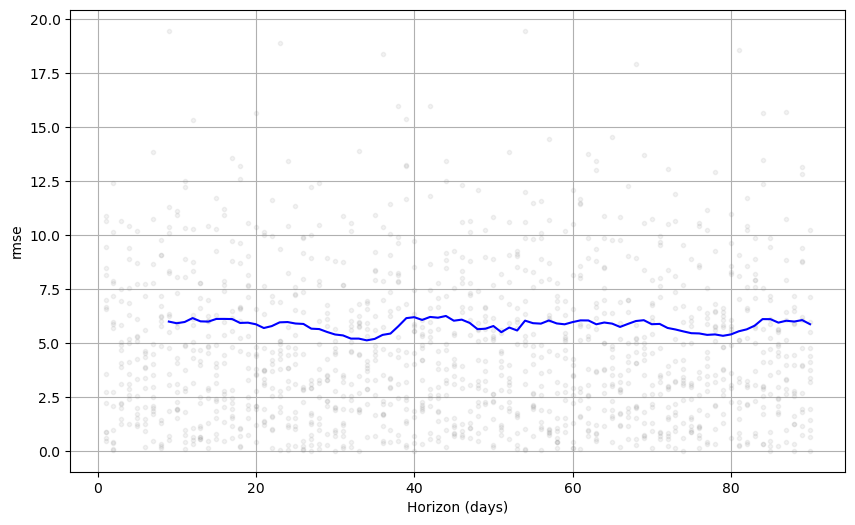

In [47]:
plot_cross_validation_metric(df_cv= cv,
                            metric= 'rmse');

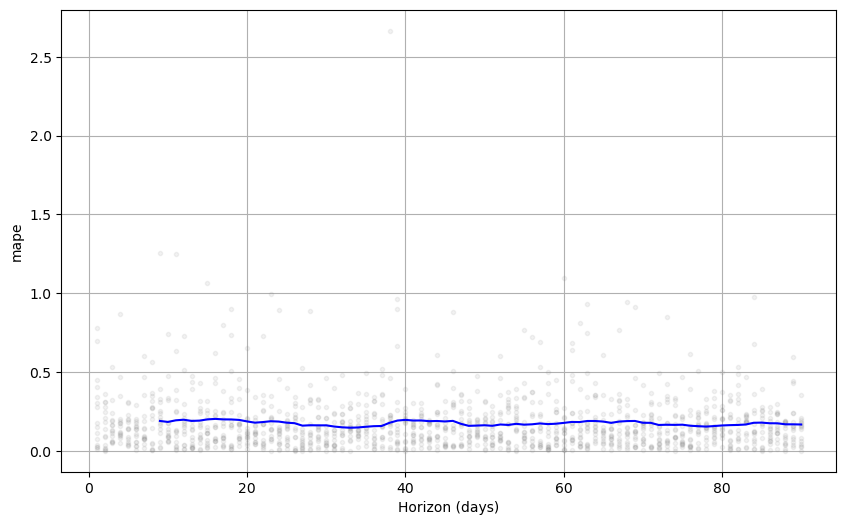

In [48]:
plot_cross_validation_metric(df_cv= cv,
                            metric= 'mape');

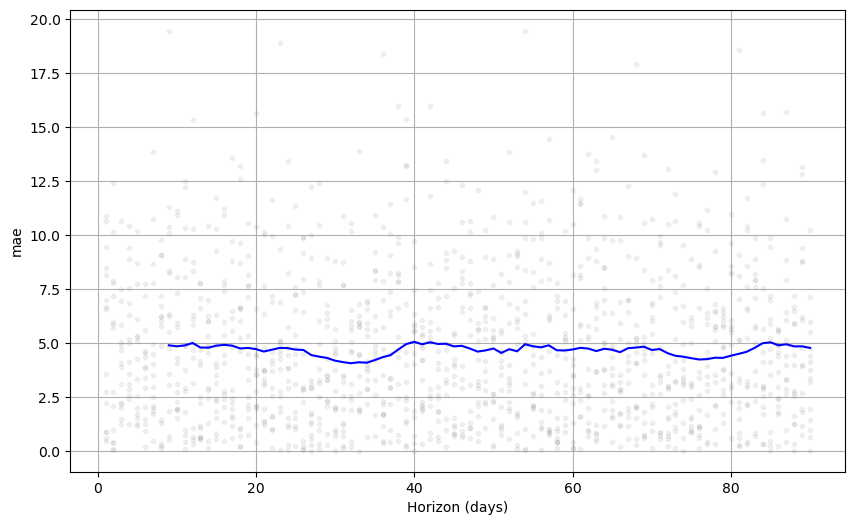

In [49]:
plot_cross_validation_metric(df_cv= cv,
                            metric= 'mae');

##### Interpreting the Plots (RMSE, MAE, MAPE):
These plots visualize how model's reliability changes as we try to predict further into the future.

- X-Axis (Horizon): Days into the future (from Day 1 to Day 90).
- Y-Axis (Error Metric): The error score (lower is better).
- Grey Dots: Individual error points from the cross-validation.
- Blue Line: The smoothed average error.